In [22]:
#Plot Bar Chart
import pandas as pd

survey_collection_df = pd.read_csv('../outputs/csv/survey_collection_deadline_adjusted.csv')
report_assignment_df = pd.read_csv('../outputs/csv/report_assignment.csv')

In [23]:
survey = 'PENDATAAN IBS TRIWULANAN 2025'
df = report_assignment_df[(report_assignment_df['name']==survey)&(report_assignment_df['type']=='progress')].copy()

In [24]:
#df = df.loc[:, df.sum() != 0]
df['kd_kab'] = df['kd_kab'].astype(str)

In [25]:
status = [
'COMPLETED BY Admin Kabupaten',
'COMPLETED BY ADMIN PROVINSI',
'clean',
'APPROVED BY ADMIN KABUPATEN',
'APPROVED BY ADMIN PROVINSI',
'APPROVED BY Admin Kabupaten',
'APPROVED BY PENGAWAS',
'APPROVED BY Pengawas',
'SUBMITTED BY PENCACAH',
'SUBMITTED BY Pencacah',
'SUBMITTED RESPONDENT',
'DRAFT',
'EDITED BY Admin Kabupaten',
'EDITED BY ADMIN KABUPATEN',
'EDITED BY Admin Pusat',
'REJECTED BY Admin Kabupaten',
'REJECTED BY PENGAWAS',
'REJECTED BY Pengawas',
'REVOKED BY Admin Kabupaten',
'REVOKED BY PENGAWAS',
'REVOKED BY Pengawas',
'OPEN',
'belum_entry']

In [26]:
categories = [x for x in status if x in df.columns.to_list()]

In [27]:
categories

['COMPLETED BY Admin Kabupaten',
 'COMPLETED BY ADMIN PROVINSI',
 'APPROVED BY ADMIN KABUPATEN',
 'APPROVED BY ADMIN PROVINSI',
 'APPROVED BY Admin Kabupaten',
 'APPROVED BY PENGAWAS',
 'APPROVED BY Pengawas',
 'SUBMITTED BY Pencacah',
 'SUBMITTED RESPONDENT',
 'DRAFT',
 'EDITED BY Admin Kabupaten',
 'EDITED BY Admin Pusat',
 'REJECTED BY Pengawas',
 'REVOKED BY Admin Kabupaten',
 'OPEN']

In [28]:
palette = {
    'COMPLETED': '#B5EAD7',
    'clean': '#B5EAD7',
    'OPEN': '#E57373',
    'belum_entry': '#E57373',
    'APPROVED': '#D3D3D3',
    'EDITED': '#ADD8E6',
    'REJECTED': '#E57373',
    'REVOKED': '#E57373',
    'SUBMITTED': '#FFF2B2',
    'DRAFT': '#E0BBE4'
}
def get_color(cat):
    first_word = cat.split()[0]   # take the first token
    return palette.get(first_word, '#999999')  # fallback color

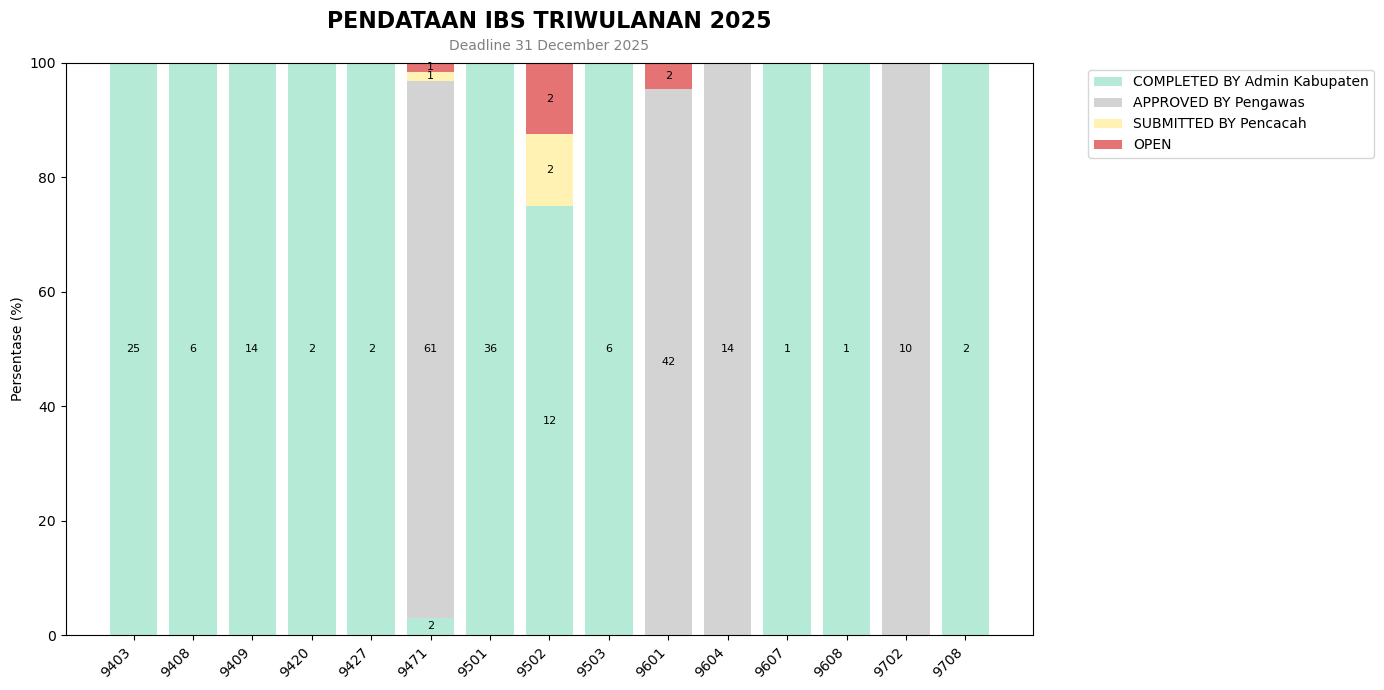

In [29]:
# build a copy with only the status/category columns
df_prop = df[categories].copy()

# drop any category columns that are all zeros so they don't silently
# disappear from the plot (we only remove them from df_prop used for plotting)
df_prop = df_prop.loc[:, df_prop.sum(axis=0) != 0]
categories = df_prop.columns.tolist()

import matplotlib.pyplot as plt
import numpy as np

# sort df by kd_kab (as string)
df = df.sort_values('kd_kab').reset_index(drop=True)

# rebuild df_prop based on the sorted df
df_prop = df[categories].copy()

row_sums = df_prop.sum(axis=1).replace(0, np.nan)
df_prop = df_prop.div(row_sums, axis=0).fillna(0)

plt.figure(figsize=(14, 7))
x = np.arange(len(df_prop))
bottom = np.zeros(len(df_prop))

for cat in categories:
    heights = df_prop[cat].values * 100        # convert to percent
    raw_vals = df[cat].values
    color = get_color(cat)

    plt.bar(
        x,
        heights,
        bottom=bottom,
        label=cat,
        color=color
    )

    # label raw values
    for i in range(len(x)):
        if raw_vals[i] > 0:
            y = bottom[i] + heights[i] / 2
            plt.text(
                x[i],
                y,
                str(int(raw_vals[i])),
                ha='center',
                va='center',
                fontsize=8
            )

    bottom += heights

plt.xticks(x, df['kd_kab'].astype(str).values, rotation=45, ha='right')
plt.ylabel("Persentase (%)")

# main title + small subtitle
plt.title(f"{survey}\n", fontsize=16, fontweight='bold')
plt.text(0.5, 1.03, "Deadline 31 December 2025",
         ha='center', va='center', transform=plt.gca().transAxes,
         fontsize=10, color='gray')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

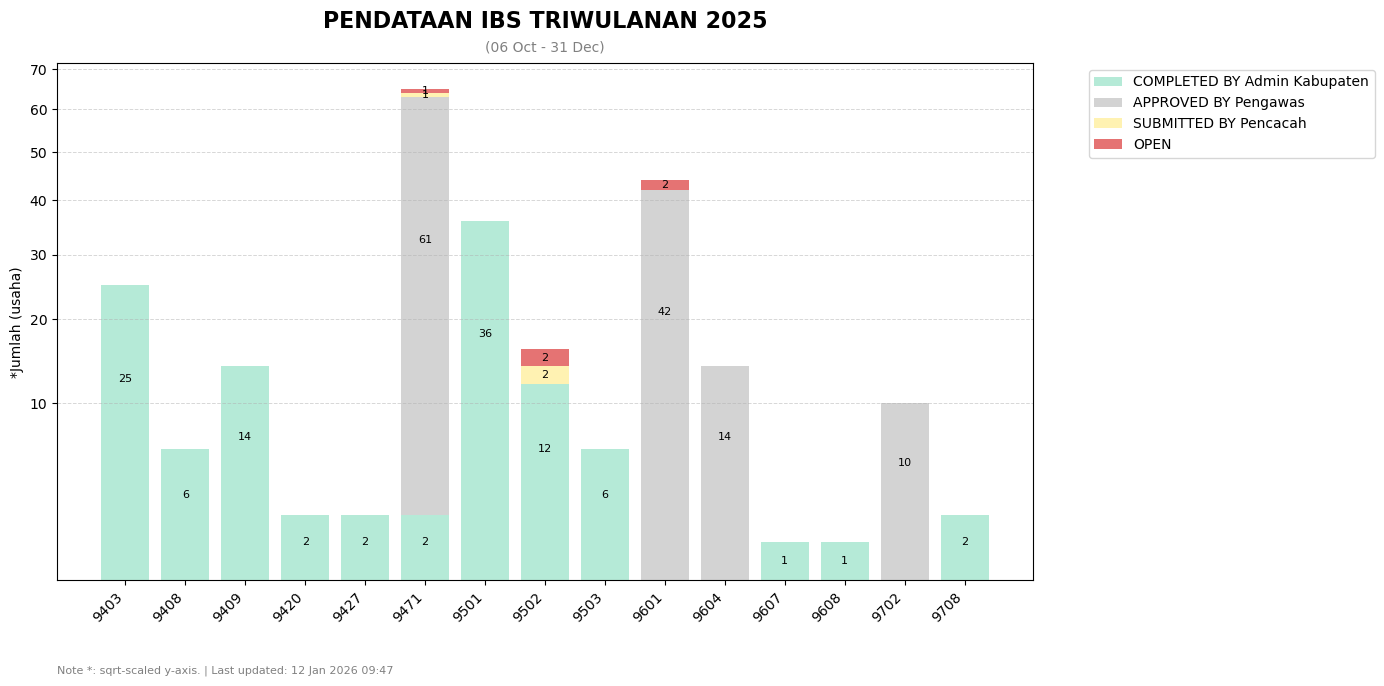

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import datetime
timestamp = datetime.datetime.now().strftime("%d %b %Y %H:%M")

# use raw counts for stacked bars
df_raw = df[categories].copy()

plt.figure(figsize=(14, 7))

x = np.arange(len(df_raw))
bottom = np.zeros(len(df_raw))

for cat in categories:
    heights = df_raw[cat].fillna(0).values
    color = get_color(cat)

    # draw bars
    plt.bar(
        x,
        heights,
        bottom=bottom,
        label=cat,
        color=color
    )

    # add labels inside each segment
    for i in range(len(x)):
        val = heights[i]
        if val > 0:
            y = bottom[i] + val / 2
            plt.text(
                x[i],
                y,
                str(int(val)),
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )

    bottom += heights

# square-root scaling on y-axis
plt.yscale("function", functions=(np.sqrt, lambda x: x**2))
plt.ylabel("*Jumlah (usaha)")

# gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

plt.xticks(
    x,
    df["kd_kab"].astype(str).values,
    rotation=45,
    ha="right"
)

# Title + subtitle
plt.title(f"{survey}\n", fontsize=16, fontweight='bold')
plt.text(
    0.5,
    1.03,
    "(06 Oct - 31 Dec)",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=10,
    color='gray'
)

# footnote about the sqrt scaling
plt.text(
    0.0,
    -0.18,
    f"Note *: sqrt-scaled y-axis. | Last updated: {timestamp}",
    transform=plt.gca().transAxes,
    fontsize=8,
    color="gray"
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

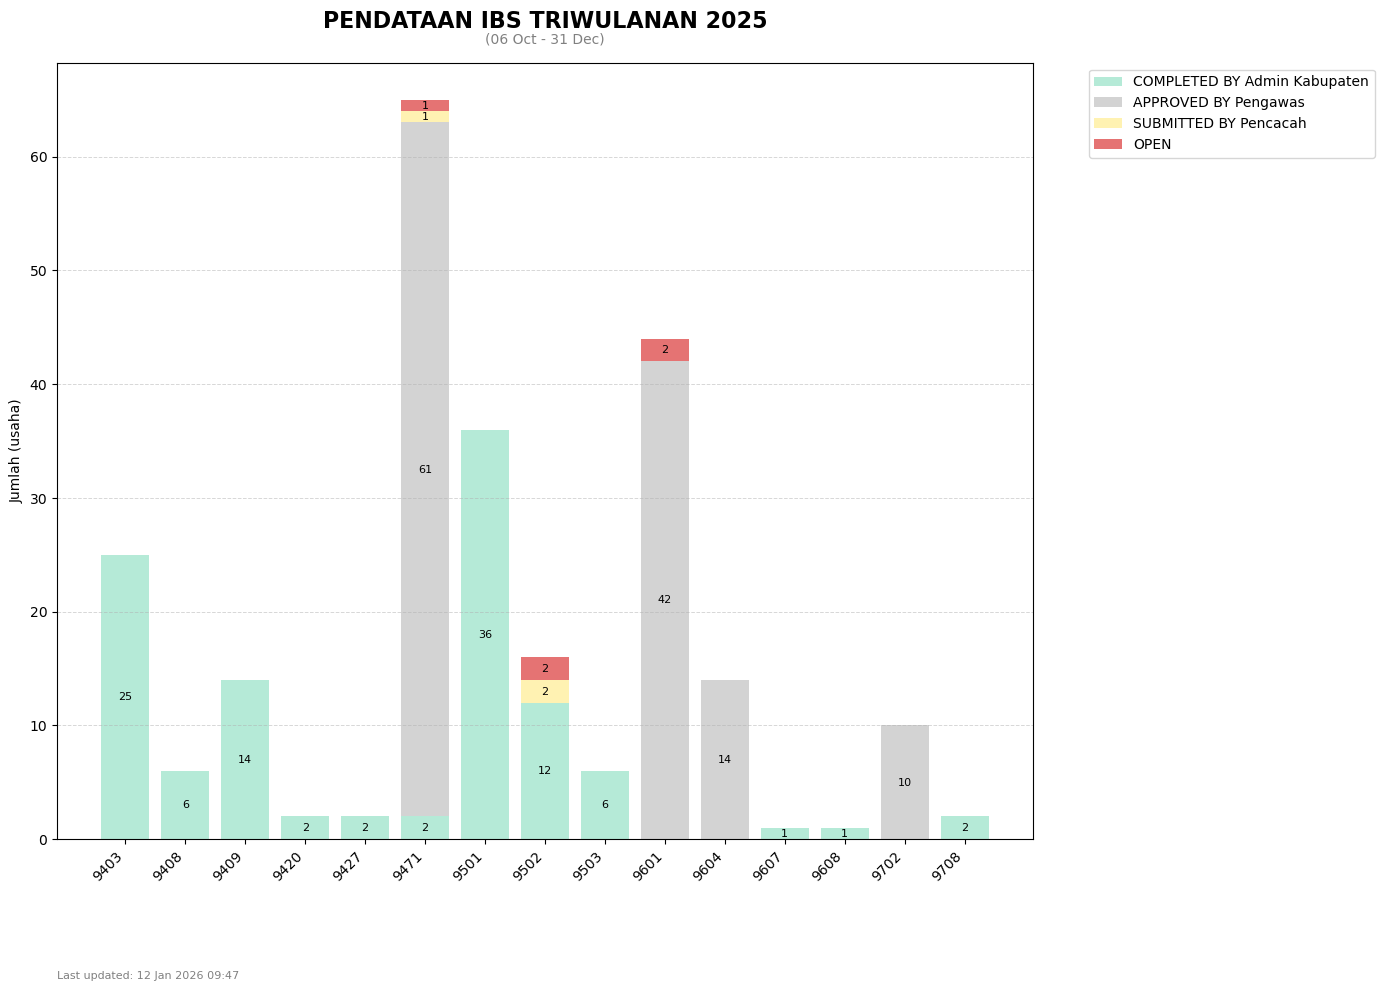

In [31]:
df_raw = df[categories].copy()

plt.figure(figsize=(14, 10))

x = np.arange(len(df_raw))
bottom = np.zeros(len(df_raw))

for cat in categories:
    heights = df_raw[cat].fillna(0).values
    color = get_color(cat)

    # draw bars
    plt.bar(
        x,
        heights,
        bottom=bottom,
        label=cat,
        color=color
    )

    # add labels inside each segment
    for i in range(len(x)):
        val = heights[i]
        if val > 0:
            y = bottom[i] + val / 2
            plt.text(
                x[i],
                y,
                str(int(val)),
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )

    bottom += heights


plt.ylabel("Jumlah (usaha)")

# gridlines
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

plt.xticks(
    x,
    df["kd_kab"].astype(str).values,
    rotation=45,
    ha="right"
)

# Title + subtitle
plt.title(f"{survey}\n", fontsize=16, fontweight='bold')
plt.text(
    0.5,
    1.03,
    "(06 Oct - 31 Dec)",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=10,
    color='gray'
)

# footnote about the sqrt scaling
plt.text(
    0.0,
    -0.18,
    f"Last updated: {timestamp}",
    transform=plt.gca().transAxes,
    fontsize=8,
    color="gray"
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
show = pd.read_csv('/Users/ronypurba/Library/CloudStorage/GoogleDrive-ronypurba@gmail.com/My Drive/projects/fasih_scrapping/input/show.csv', sep=';')


In [33]:
show_ls = show.loc[show['show']==1,'name'].squeeze().tolist()

In [34]:
show.columns

Index(['name', 'show'], dtype='object')